In [2]:
import os
import shutil
import random

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split

import matplotlib.pyplot as plt
from tqdm import tqdm

from PIL import Image

# check if GPU is available, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [3]:
!pip install -q kagglehub

import kagglehub


dataset_path = kagglehub.dataset_download("iamsouravbanerjee/indian-food-images-dataset")
print("Dataset downloaded to:", dataset_path)


100%|██████████| 355M/355M [00:02<00:00, 140MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/iamsouravbanerjee/indian-food-images-dataset/versions/5


In [6]:
extracted_root = dataset_path

dataset_root = None
for root, dirs, files in os.walk(extracted_root):
    # a valid dataset folder should contain many subfolders (food classes)
    if len(dirs) > 10:
        dataset_root = root
        break

print("Found dataset folder at:", dataset_root)
print("Available classes:", os.listdir(dataset_root)[:10], "...")


Found dataset folder at: /root/.cache/kagglehub/datasets/iamsouravbanerjee/indian-food-images-dataset/versions/5/Indian Food Images/Indian Food Images
Available classes: ['kachori', 'chicken_tikka_masala', 'litti_chokha', 'kadai_paneer', 'cham_cham', 'poha', 'aloo_gobi', 'dal_makhani', 'sheer_korma', 'kofta'] ...


In [7]:
# the 5 classes we want to use for this project

selected_classes = {
    "Biryani": ["biryani"],
    "kachori": ["kachori"],
    "Jalebi": ["jalebi"],
    "Poha": ["poha"],
    "aloo_tikki": ["aloo_tikki"]
}

# folder where we will store only our selected classes
final_data_dir = "food_data"
os.makedirs(final_data_dir, exist_ok=True)

available_folders = os.listdir(dataset_root)

for class_name, possible_names in selected_classes.items():
    # find the matching folder name from the dataset
    match = None
    for name in possible_names:
        if name in available_folders:
            match = name
            break

    if match is None:
        print(f"Warning: could not find a folder for class '{class_name}'")
        continue

    source_folder = os.path.join(dataset_root, match)
    target_folder = os.path.join(final_data_dir, class_name)
    os.makedirs(target_folder, exist_ok=True)

    # copy all images from the source folder to our new folder
    for file_name in os.listdir(source_folder):
        src = os.path.join(source_folder, file_name)
        dst = os.path.join(target_folder, file_name)
        if not os.path.exists(dst):
            shutil.copy(src, dst)

    print(f"Copied {len(os.listdir(target_folder))} images for class '{class_name}'")


Copied 50 images for class 'Biryani'
Copied 50 images for class 'kachori'
Copied 50 images for class 'Jalebi'
Copied 50 images for class 'Poha'
Copied 50 images for class 'aloo_tikki'


In [8]:
# ImageNet mean and std values
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

# transforms used for training data
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

# transforms used for validation data
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])


In [9]:
# load dataset once just to get the class names and total size
full_dataset = datasets.ImageFolder(root=final_data_dir)

class_names = full_dataset.classes
print("Classes found:", class_names)
print("Total images:", len(full_dataset))

# calculate split sizes: 80% train, 20% validation
total_size = len(full_dataset)
train_size = int(0.8 * total_size)
val_size = total_size - train_size

print(f"Training images: {train_size}")
print(f"Validation images: {val_size}")


Classes found: ['Biryani', 'Jalebi', 'Poha', 'aloo_tikki', 'kachori']
Total images: 250
Training images: 200
Validation images: 50


In [10]:
# set a manual seed so the split is the same every time we run this notebook
torch.manual_seed(42)

# load the dataset twice, with the two different transforms
train_dataset_full = datasets.ImageFolder(root=final_data_dir, transform=train_transforms)
val_dataset_full = datasets.ImageFolder(root=final_data_dir, transform=val_transforms)

# split indices using random_split
indices = torch.randperm(total_size)
train_indices = indices[:train_size]
val_indices = indices[train_size:]

train_dataset = torch.utils.data.Subset(train_dataset_full, train_indices)
val_dataset = torch.utils.data.Subset(val_dataset_full, val_indices)

# create DataLoaders
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print("Number of training batches:", len(train_loader))
print("Number of validation batches:", len(val_loader))


Number of training batches: 7
Number of validation batches: 2


### Visualizing a few sample images

Let's plot a few training images along with their labels, just to confirm our data is loading correctly.


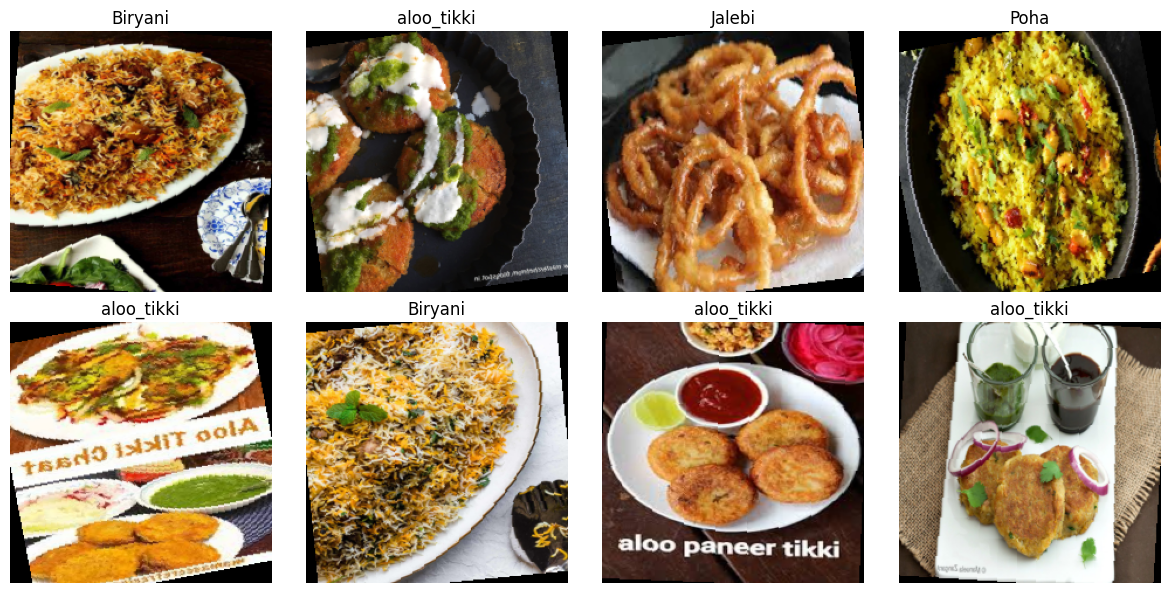

In [11]:
# function to unnormalize an image so it can be displayed properly
def unnormalize(img_tensor):
    img = img_tensor.clone()
    for t, m, s in zip(img, imagenet_mean, imagenet_std):
        t.mul_(s).add_(m)
    return img

# get one batch of training images
sample_images, sample_labels = next(iter(train_loader))

plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    img = unnormalize(sample_images[i]).permute(1, 2, 0).numpy().clip(0, 1)
    plt.imshow(img)
    plt.title(class_names[sample_labels[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()


In [12]:
# load pretrained EfficientNet-B0
efficientnet = models.efficientnet_b0(weights="IMAGENET1K_V1")

# let's look at the model's classifier layer (the final fully connected layer)
print(efficientnet.classifier)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 148MB/s]

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)


In [13]:
# freeze all the parameters in the convolution layers
for param in efficientnet.features.parameters():
    param.requires_grad = False

# check how many input features the original classifier expects
num_features = efficientnet.classifier[1].in_features
print("Number of input features to classifier:", num_features)

num_classes = len(class_names)

# replace the final classifier layer with a new one for our 5 food classes
efficientnet.classifier[1] = nn.Linear(num_features, num_classes)

# move the model to GPU
model = efficientnet.to(device)

print(model.classifier)


Number of input features to classifier: 1280
Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=5, bias=True)
)


In [14]:
criterion = nn.CrossEntropyLoss()


In [15]:
# only optimize the parameters that require gradients
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)


In [16]:
num_epochs = 10

# lists to store loss values for plotting later
train_losses = []
val_losses = []
val_accuracies = []

best_val_accuracy = 0.0

for epoch in range(num_epochs):

    # Training Phase

    model.train()  # set model to training mode
    running_train_loss = 0.0

    train_progress = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Training]")

    for images, labels in train_progress:
        images, labels = images.to(device), labels.to(device)

        # 1. Forward pass
        outputs = model(images)

        # 2. Loss calculation
        loss = criterion(outputs, labels)

        # 3. Backpropagation
        optimizer.zero_grad()
        loss.backward()

        # 4. Optimizer step
        optimizer.step()

        running_train_loss += loss.item() * images.size(0)
        train_progress.set_postfix(loss=loss.item())

    epoch_train_loss = running_train_loss / len(train_dataset)
    train_losses.append(epoch_train_loss)


    # Validation Phase

    model.eval()
    running_val_loss = 0.0
    correct_predictions = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * images.size(0)

            # get the class with highest score as our prediction
            _, predicted = torch.max(outputs, 1)
            correct_predictions += (predicted == labels).sum().item()

    epoch_val_loss = running_val_loss / len(val_dataset)
    epoch_val_accuracy = correct_predictions / len(val_dataset)

    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_accuracy)

    print(f"Epoch {epoch+1}/{num_epochs} -> "
          f"Train Loss: {epoch_train_loss:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} | "
          f"Val Accuracy: {epoch_val_accuracy*100:.2f}%")

    # save the model only if validation accuracy improved
    if epoch_val_accuracy > best_val_accuracy:
        best_val_accuracy = epoch_val_accuracy
        torch.save(model.state_dict(), "food_classifier.pth")
        print("Best model saved!")


Epoch 1/10 [Training]: 100%|██████████| 7/7 [00:03<00:00,  1.96it/s, loss=1.35]


Epoch 1/10 -> Train Loss: 1.5456 | Val Loss: 1.3344 | Val Accuracy: 62.00%
Best model saved!


Epoch 2/10 [Training]: 100%|██████████| 7/7 [00:02<00:00,  3.40it/s, loss=1.38]


Epoch 2/10 -> Train Loss: 1.2843 | Val Loss: 1.1359 | Val Accuracy: 70.00%
Best model saved!


Epoch 3/10 [Training]: 100%|██████████| 7/7 [00:02<00:00,  3.45it/s, loss=1.1]


...

Epoch 8/10 -> Train Loss: 0.6012 | Val Loss: 0.6541 | Val Accuracy: 88.00%


Epoch 9/10 [Training]: 100%|██████████| 7/7 [00:02<00:00,  2.59it/s, loss=0.717]


Epoch 9/10 -> Train Loss: 0.5665 | Val Loss: 0.5977 | Val Accuracy: 88.00%


Epoch 10/10 [Training]: 100%|██████████| 7/7 [00:02<00:00,  3.40it/s, loss=1.15]


Epoch 10/10 -> Train Loss: 0.5660 | Val Loss: 0.5711 | Val Accuracy: 90.00%


In [17]:
print(f"Best Validation Accuracy achieved: {best_val_accuracy*100:.2f}%")


Best Validation Accuracy achieved: 90.00%


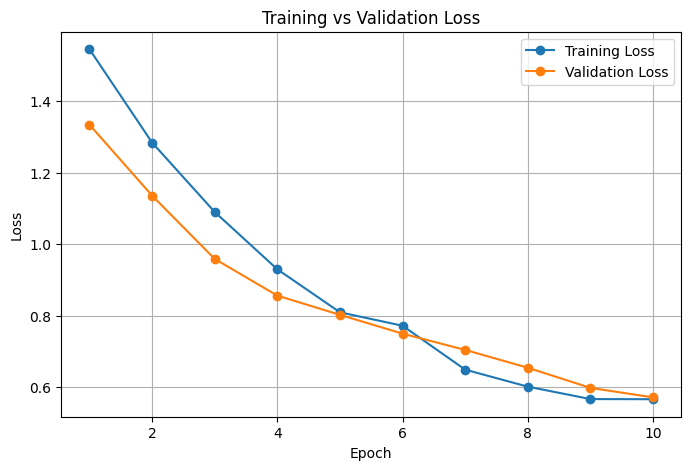

In [18]:
epochs_range = range(1, num_epochs + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_losses, label="Training Loss", marker="o")
plt.plot(epochs_range, val_losses, label="Validation Loss", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


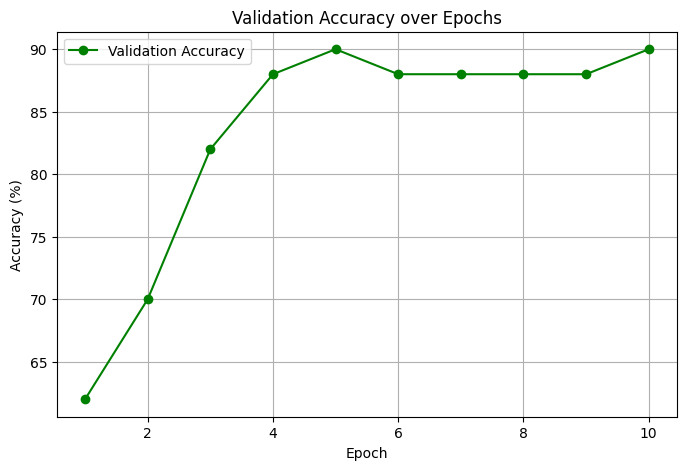

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, [acc * 100 for acc in val_accuracies], label="Validation Accuracy", marker="o", color="green")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Validation Accuracy over Epochs")
plt.legend()
plt.grid(True)
plt.show()


In [20]:
print("Model already saved as food_classifier.pth during training (best validation accuracy).")


from google.colab import files
files.download("food_classifier.pth")


Model already saved as food_classifier.pth during training (best validation accuracy).


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
# recreate the same architecture
loaded_model = models.efficientnet_b0(weights=None)  # weights=None since we will load our own weights
num_features = loaded_model.classifier[1].in_features
loaded_model.classifier[1] = nn.Linear(num_features, num_classes)

# load the saved weights
loaded_model.load_state_dict(torch.load("food_classifier.pth", map_location=device))
loaded_model = loaded_model.to(device)

# set to evaluation mode
loaded_model.eval()

print("Model loaded successfully!")


Model loaded successfully!


In [22]:
# upload a new food image to test the model
uploaded_image = files.upload()

# get the uploaded file name
image_path = list(uploaded_image.keys())[0]


Saving pngtree-biryani-with-vegetables-png-image_15366619.webp to pngtree-biryani-with-vegetables-png-image_15366619.webp


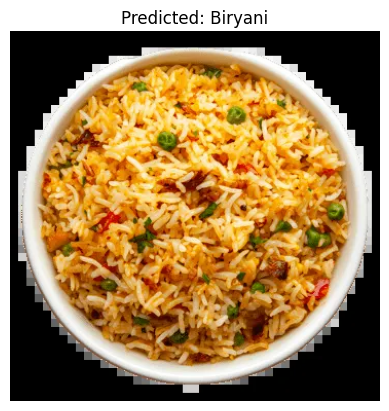

Predicted Food Class: Biryani


In [23]:
def predict_image(image_path, model):
    # open the image and convert to RGB
    image = Image.open(image_path).convert("RGB")

    # apply the same transforms used for validation
    input_tensor = val_transforms(image)
    input_batch = input_tensor.unsqueeze(0).to(device)  # add batch dimension

    model.eval()
    with torch.no_grad():
        output = model(input_batch)
        _, predicted_index = torch.max(output, 1)

    predicted_class = class_names[predicted_index.item()]

    # display the image with the predicted label
    plt.imshow(image)
    plt.title(f"Predicted: {predicted_class}")
    plt.axis("off")
    plt.show()

    return predicted_class

predicted_class = predict_image(image_path, loaded_model)
print("Predicted Food Class:", predicted_class)
